In [1]:
%pip install snntorch
import numpy as np
import torch
import torch.nn as nn
import numpy as np
import snntorch as snn
import random
from snntorch import utils
from snntorch import spikegen, surrogate
import snntorch.functional as SF
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.patches as mpatches
from torch.nn.functional import cross_entropy
import torch.nn.functional as F
from torch.utils.data import Subset
# -------------- Parameters -----------------------
time_steps = 39512

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Helper functions:
def create_sequences(inputs, labels, window_size, stride=5):
    X, Y = [], []
    for i in range(0, len(inputs) - window_size, stride):
        X.append(inputs[i : i + window_size])
        Y.append(labels[i + window_size - 1])
    return torch.stack(X), torch.stack(Y)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha  # weights
        self.gamma = gamma 
        self.reduction = reduction
    
    def forward(self, logits, targets):
        ce_loss = cross_entropy(logits, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_weight = (1 - pt) ** self.gamma  
        loss = focal_weight * ce_loss
        
        if self.reduction == 'mean':
            return loss.mean()
        return loss.sum()


def per_class_accuracy(data_loader, net, device, num_classes=3):
    net.eval()
    correct = torch.zeros(num_classes)
    total = torch.zeros(num_classes)
    with torch.no_grad():
        for data, targets in data_loader:
            data = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()
            logits = net(data)
            preds = logits.argmax(dim=1)
            for c in range(num_classes):
                mask = targets == c
                total[c] += mask.sum().item()
                correct[c] += (preds[mask] == c).sum().item()
    return (correct / total.clamp(min=1)).cpu().numpy()
    
def evaluate_epoch(data_loader, net, loss_fn, device, num_classes=3):
    """Single pass: returns per-class loss AND per-class accuracy together"""
    net.eval()
    class_losses = [[] for _ in range(num_classes)]
    correct = torch.zeros(num_classes)
    total = torch.zeros(num_classes)
    
    with torch.no_grad():
        for data, targets in data_loader:
            data = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()
            
            logits = net(data)  # ONE forward pass per batch, not two
            preds = logits.argmax(dim=1)
            
            for c in range(num_classes):
                mask = targets == c
                if mask.sum() > 0:
                    class_loss = loss_fn(logits[mask], targets[mask])
                    class_losses[c].append(class_loss.item())
                total[c] += mask.sum().item()
                correct[c] += (preds[mask] == c).sum().item()
    
    avg_losses = [np.mean(l) if l else float('nan') for l in class_losses]
    per_class_acc = (correct / total.clamp(min=1)).cpu().numpy()
    return avg_losses, per_class_acc
    
def compute_loss_per_class(data_loader, net, loss_fn, device, num_classes=3):
    """compute loss for each class separately"""
    net.eval()
    class_losses = [[] for _ in range(num_classes)]
    
    with torch.no_grad():
        for data, targets in data_loader:
            data = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()
            
            logits = net(data)
            
            # compute loss for each sample then group by class really dont know why!!!
            for c in range(num_classes):
                mask = targets == c
                if mask.sum() > 0:
                    class_logits = logits[mask]
                    class_targets = targets[mask]
                    class_loss = loss_fn(class_logits, class_targets)
                    class_losses[c].append(class_loss.item())
    
    # avg per class
    avg_losses = [np.mean(losses) if losses else float('nan') for losses in class_losses]
    return avg_losses


def plot_loss_per_class(train_loader, test_loader, net, loss_fn, device, epoch=25):
    train_losses = compute_loss_per_class(train_loader, net, loss_fn, device)
    test_losses = compute_loss_per_class(test_loader, net, loss_fn, device)
    
    classes = ['Up', 'Stationary', 'Down']
    x = np.arange(len(classes))
    width = 0.35
    
    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, train_losses, width, label='Train Loss', alpha=0.8)
    plt.bar(x + width/2, test_losses, width, label='Test Loss', alpha=0.8)
    
    plt.xlabel('Class')
    plt.ylabel('Cross Entropy Loss (focal loss)')
    plt.title(f'Loss Per Class (Final Epoch {epoch} )')
    plt.xticks(x, classes)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("train loss per class:", [f"{l:.4f}" for l in train_losses])
    print("test loss per class:", [f"{l:.4f}" for l in test_losses])

 
def weights(device, labels, smoothing=.15):
    class_counts = torch.bincount(labels.long())
    total_samples = len(labels)
    
    smoothed_c = class_counts.float() + (smoothing * total_samples / len(class_counts))
    dynamic_weights = total_samples / (len(class_counts) * smoothed_c)
    print(dynamic_weights)
    return dynamic_weights.to(device=device)

In [3]:
class STEQuantize(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, num_levels):
        scaled = x * (num_levels - 1)
        quantized = torch.round(scaled)
        return quantized / (num_levels - 1)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None

class MemristorCrossbarLinear(nn.Module):
    def __init__(self, in_features, out_features, num_levels=16, saf_rate=0.02, noise_std=0.03):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_levels = num_levels
        self.noise_std = noise_std
        self.saf_rate = saf_rate
        self.force_noise_eval = False  
        
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))
        
        nn.init.normal_(self.weight, mean=0.0, std=0.05)
        nn.init.zeros_(self.bias)
        
        self.register_buffer('saf_g_pos_lrs', torch.zeros(out_features, in_features, dtype=torch.bool), persistent=False)
        self.register_buffer('saf_g_pos_hrs', torch.zeros(out_features, in_features, dtype=torch.bool), persistent=False)
        self.register_buffer('saf_g_neg_lrs', torch.zeros(out_features, in_features, dtype=torch.bool), persistent=False)
        self.register_buffer('saf_g_neg_hrs', torch.zeros(out_features, in_features, dtype=torch.bool), persistent=False)
        
        self.generate_saf_masks(saf_rate)

    def generate_saf_masks(self, saf_rate):
        self.saf_rate = saf_rate
        device = self.weight.device
        
        self.saf_g_pos_lrs.copy_(torch.rand(self.out_features, self.in_features, device=device) < (saf_rate / 2))
        self.saf_g_pos_hrs.copy_(torch.rand(self.out_features, self.in_features, device=device) < (saf_rate / 2))
        self.saf_g_neg_lrs.copy_(torch.rand(self.out_features, self.in_features, device=device) < (saf_rate / 2))
        self.saf_g_neg_hrs.copy_(torch.rand(self.out_features, self.in_features, device=device) < (saf_rate / 2))

    def get_physical_weights(self):
        """Extracts the quantized, noisy physical weight matrix ONCE."""
        weight_scale = torch.max(torch.abs(self.weight)).detach().clamp(min=1e-5)
        w_normalized = torch.clamp(self.weight / weight_scale, -1.0, 1.0)
        
        g_pos = (w_normalized + 1.0) / 2.0
        g_neg = (1.0 - w_normalized) / 2.0
        
        # Apply SAF defects
        g_pos = torch.where(self.saf_g_pos_lrs, torch.ones_like(g_pos), g_pos)
        g_pos = torch.where(self.saf_g_pos_hrs, torch.zeros_like(g_pos), g_pos)
        g_neg = torch.where(self.saf_g_neg_lrs, torch.ones_like(g_neg), g_neg)
        g_neg = torch.where(self.saf_g_neg_hrs, torch.zeros_like(g_neg), g_neg)
        
        # Finite State Quantization
        g_pos_q = STEQuantize.apply(g_pos, self.num_levels)
        g_neg_q = STEQuantize.apply(g_neg, self.num_levels)
        
        if (self.training or self.force_noise_eval) and self.noise_std > 0:
            noise_pos = torch.randn_like(g_pos_q) * self.noise_std
            noise_neg = torch.randn_like(g_neg_q) * self.noise_std
            g_pos_q = torch.clamp(g_pos_q + noise_pos, 0.0, 1.0)
            g_neg_q = torch.clamp(g_neg_q + noise_neg, 0.0, 1.0)
            
        return (g_pos_q - g_neg_q) * weight_scale

    def forward(self, x):
        w_physical = self.get_physical_weights()
        return F.linear(x, w_physical, self.bias)
    

def reset_to_clean_eval_state(net, saf_rate=0.0, noise_std=0.0):
        for name, module in net.named_modules():
            if isinstance(module, MemristorCrossbarLinear):
                module.generate_saf_masks(saf_rate)
                module.noise_std = noise_std
                module.force_noise_eval = False

In [4]:
import glob
import gc
from torch.utils.data import Dataset, ConcatDataset, DataLoader

class LOBDayDataset(Dataset):
    def __init__(self, filepath, window_size=30, stride=5, delta_threshold=0.005):
        data = np.loadtxt(filepath)
        features = data[:144, :].T
        labels = data[146, :].T - 1
        del data

        features_tensor = torch.from_numpy(features).float()
        labels_tensor = torch.from_numpy(labels).long()
        del features, labels

        spike = spikegen.delta(features_tensor, threshold=delta_threshold, padding=True, off_spike=True)
        spikes_pos = torch.where(spike > 0, spike, torch.zeros_like(spike))
        spikes_neg = torch.where(spike < 0, torch.abs(spike), torch.zeros_like(spike))
        del spike, features_tensor

        inputs = torch.cat((spikes_pos, spikes_neg), dim=1).half()  # float16 -> halves memory
        del spikes_pos, spikes_neg

        self.X, self.Y = self._create_sequences(inputs, labels_tensor, window_size, stride)
        del inputs, labels_tensor
        gc.collect()

    def _create_sequences(self, inputs, labels, window_size, stride):
        X, Y = [], []
        for i in range(0, len(inputs) - window_size, stride):
            X.append(inputs[i : i + window_size])
            Y.append(labels[i + window_size - 1])
        return torch.stack(X), torch.stack(Y)

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X[idx].float(), self.Y[idx]  # cast back per-sample, not stored as float32


# ---- Build combined training set from all 9 days ----
train_files = sorted(glob.glob(
    "/kaggle/input/datasets/firmwired/fi-2010/data/published/BenchmarkDatasets/BenchmarkDatasets/BenchmarkDatasets/NoAuction/NoAuction_MinMax/NoAuction_MinMax_Training/Train_Dst_NoAuction_MinMax_CF_*.txt"
))
print(f"Found {len(train_files)} training files")

train_datasets = []
for f in train_files:
    print(f"Loading {f.split('/')[-1]}...")
    ds = LOBDayDataset(f, window_size=30, stride=5, delta_threshold=0.005)
    train_datasets.append(ds)
    print(f"  -> {len(ds)} windows")

full_train_dataset = ConcatDataset(train_datasets)
print(f"Total training windows: {len(full_train_dataset)}")

train_loader = DataLoader(full_train_dataset, batch_size=256, shuffle=True,
                           pin_memory=True, num_workers=4)
 
test_files = sorted(glob.glob(
    "/kaggle/input/datasets/firmwired/fi-2010/data/published/BenchmarkDatasets/BenchmarkDatasets/BenchmarkDatasets/NoAuction/NoAuction_MinMax/NoAuction_MinMax_Testing/Test_Dst_NoAuction_MinMax_CF_*.txt"
))
print(f"Found {len(test_files)} test files")

test_datasets = []
for f in test_files:
    print(f"Loading {f.split('/')[-1]}...")
    ds = LOBDayDataset(f, window_size=30, stride=5, delta_threshold=0.005)
    test_datasets.append(ds)
    print(f"  -> {len(ds)} windows")

full_test_dataset = ConcatDataset(test_datasets)
print(f"Total test windows: {len(full_test_dataset)}")

test_loader = DataLoader(full_test_dataset, batch_size=256, shuffle=False, pin_memory=True)
 

Found 9 training files
Loading Train_Dst_NoAuction_MinMax_CF_1.txt...
  -> 7897 windows
Loading Train_Dst_NoAuction_MinMax_CF_2.txt...
  -> 15576 windows
Loading Train_Dst_NoAuction_MinMax_CF_3.txt...
  -> 21283 windows
Loading Train_Dst_NoAuction_MinMax_CF_4.txt...
  -> 28688 windows
Loading Train_Dst_NoAuction_MinMax_CF_5.txt...
  -> 35645 windows
Loading Train_Dst_NoAuction_MinMax_CF_6.txt...
  -> 43475 windows
Loading Train_Dst_NoAuction_MinMax_CF_7.txt...
  -> 50944 windows
Loading Train_Dst_NoAuction_MinMax_CF_8.txt...
  -> 62040 windows
Loading Train_Dst_NoAuction_MinMax_CF_9.txt...
  -> 72474 windows
Total training windows: 338022
Found 9 test files
Loading Test_Dst_NoAuction_MinMax_CF_1.txt...
  -> 7674 windows
Loading Test_Dst_NoAuction_MinMax_CF_2.txt...
  -> 5701 windows
Loading Test_Dst_NoAuction_MinMax_CF_3.txt...
  -> 7399 windows
Loading Test_Dst_NoAuction_MinMax_CF_4.txt...
  -> 6951 windows
Loading Test_Dst_NoAuction_MinMax_CF_5.txt...
  -> 7825 windows
Loading Test_D

In [5]:
num_inputs = 288
num_hidden = 128
num_outputs = 3
beta = .9
window_size = 30  
spike_grad = surrogate.fast_sigmoid(slope=25)
best_test_loss = float('inf')
patience = 15
patience_counter = 0
best_test_metric = 0.0
 
 
class HFT_Net_Optimized(nn.Module):
    def __init__(self, num_levels=16, saf_rate=0.02, noise_std=0.03):
        super().__init__()
        self.fc1  = MemristorCrossbarLinear(num_inputs, num_hidden, 
                                            num_levels=num_levels, saf_rate=saf_rate, noise_std=noise_std)
        self.lif1 = snn.Leaky(threshold=0.5, beta=beta, spike_grad=spike_grad)
        
        self.drop = nn.Dropout(0.3) 
        
        self.fc2  = MemristorCrossbarLinear(num_hidden, num_outputs, 
                                            num_levels=num_levels, saf_rate=saf_rate, noise_std=noise_std)
        self.lif2 = snn.Leaky(threshold=1.0, beta=beta, spike_grad=spike_grad, reset_mechanism="none")  
        
    def forward(self, x):
        x = x.permute(1, 0, 2) # (Time, Batch, Features)
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        
        # 1. Compute ALL Layer 1 currents in one shot (Vectorized over Time & Batch)
        cur1_all = self.fc1(x) 
        
        # 2. Extract Layer 2's physical weights ONCE before the loop begins
        w_phys2 = self.fc2.get_physical_weights()
        bias2 = self.fc2.bias
        
        for step in range(x.shape[0]):
            spk1, mem1 = self.lif1(cur1_all[step], mem1)
            
            spk1_dropped = self.drop(spk1) 
            
            # 3. Apply the cached weights to avoid recalculating noise/quantization
            cur2 = F.linear(spk1_dropped, w_phys2, bias2)
            spk2, mem2 = self.lif2(cur2, mem2)
            
        return mem2
    
num_epochs = 40
loss_hist = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

torch.manual_seed(123) 
net = HFT_Net_Optimized(num_levels=16, saf_rate=0.02, noise_std=0.03).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999), weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
 
all_labels = torch.cat([ds.Y for ds in train_datasets])
w = weights(device=device, labels=all_labels)
loss_fn = FocalLoss(alpha=w, gamma=2)
sample_data, sample_targets = next(iter(train_loader))
print(f"train_loader batch shape: {sample_data.shape}, {len(train_loader)}")  # expect (batch, window_size, 288)
assert sample_data.dim() == 3, f"Expected 3D input, got {sample_data.dim()}D — check which train_loader is active!" 

eval_subset_size = min(5000, len(full_test_dataset))
eval_indices = random.sample(range(len(full_test_dataset)), eval_subset_size)
eval_subset = Subset(full_test_dataset, eval_indices)
eval_subset_loader = DataLoader(eval_subset, batch_size=256, shuffle=False, pin_memory=True)


for epoch in range(num_epochs):
    net.train()
    print("start")
    for batch_idx, (data, targets) in enumerate(train_loader):
        data = data.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).long()
        
        # 1. DYNAMIC INJECTION: Randomize defects for every training batch
        for name, module in net.named_modules():
            if isinstance(module, MemristorCrossbarLinear):
                module.generate_saf_masks(saf_rate=0.03) # Training at 3% SAF
                module.noise_std = 0.05                 # Training at 5% Noise
        
        optimizer.zero_grad(set_to_none=True)
        
        # 2. Forward pass (now includes randomized noise/SAF)
        logits = net(data)
        loss_val = loss_fn(logits, targets)
        
        loss_val.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        optimizer.step()
         
            
        
        loss_hist.append(loss_val.item())
        pass
    scheduler.step()
    
    net.eval()
    reset_to_clean_eval_state(net, saf_rate=0.0, noise_std=0.0) 
    test_losses, test_per_class = evaluate_epoch(eval_subset_loader, net, loss_fn, device)
    avg_test_loss = np.nanmean(test_losses)
    mean_test_acc = test_per_class.mean()
    print(f"acc {mean_test_acc}")
   
    # Save the model based on the highest balanced accuracy, NOT the lowest loss!
    if mean_test_acc > best_test_metric:
        best_test_metric = mean_test_acc
        patience_counter = 0
        torch.save(net.state_dict(), 'best_model.pt')
        print(f"Epoch {epoch}: NEW BEST CHECKPOINT | Mean Acc: {mean_test_acc*100:.2f}% | Loss: {avg_test_loss:.4f}")
    else:
        patience_counter += 1 
        print(f"Epoch {epoch}: Mean Acc: {mean_test_acc*100:.2f}% | Loss: {avg_test_loss:.4f} (Patience: {patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}.")
            break
    print(f"**** epoch {epoch} complete ****\n")
    
net.load_state_dict(torch.load('best_model.pt', map_location=device))
net.eval()
reset_to_clean_eval_state(net, saf_rate=0.0, noise_std=0.0) 
print(f"Reloaded best checkpoint")

cuda
tensor([0.9954, 0.6822, 1.0209])
train_loader batch shape: torch.Size([256, 30, 288]), 1321
start
acc 0.5084989666938782
Epoch 0: NEW BEST CHECKPOINT | Mean Acc: 50.85% | Loss: 0.3429
**** epoch 0 complete ****

start
acc 0.5085374116897583
Epoch 1: NEW BEST CHECKPOINT | Mean Acc: 50.85% | Loss: 0.3469
**** epoch 1 complete ****

start
acc 0.49549564719200134
Epoch 2: Mean Acc: 49.55% | Loss: 0.3385 (Patience: 1/15)
**** epoch 2 complete ****

start
acc 0.48099076747894287
Epoch 3: Mean Acc: 48.10% | Loss: 0.3429 (Patience: 2/15)
**** epoch 3 complete ****

start
acc 0.5068730115890503
Epoch 4: Mean Acc: 50.69% | Loss: 0.3350 (Patience: 3/15)
**** epoch 4 complete ****

start
acc 0.4865400493144989
Epoch 5: Mean Acc: 48.65% | Loss: 0.3341 (Patience: 4/15)
**** epoch 5 complete ****

start
acc 0.48962196707725525
Epoch 6: Mean Acc: 48.96% | Loss: 0.3384 (Patience: 5/15)
**** epoch 6 complete ****

start
acc 0.4937375485897064
Epoch 7: Mean Acc: 49.37% | Loss: 0.3405 (Patience: 6/15

In [6]:
print(f"num_epochs variable currently: {num_epochs}")
print(f"scheduler T_max: {scheduler.T_max}")
print(f"Total loss_hist entries: {len(loss_hist)}")
print(f"Batches per epoch: {len(train_loader)}")
print(f"Epochs actually completed: {len(loss_hist) / len(train_loader):.1f}")
import os, time
print(f"best_model.pt last modified: {time.ctime(os.path.getmtime('best_model.pt'))}")
print(f"Current time: {time.ctime()}")

num_epochs variable currently: 40
scheduler T_max: 40
Total loss_hist entries: 22457
Batches per epoch: 1321
Epochs actually completed: 17.0
best_model.pt last modified: Fri Jul 17 23:46:39 2026
Current time: Sat Jul 18 00:03:18 2026


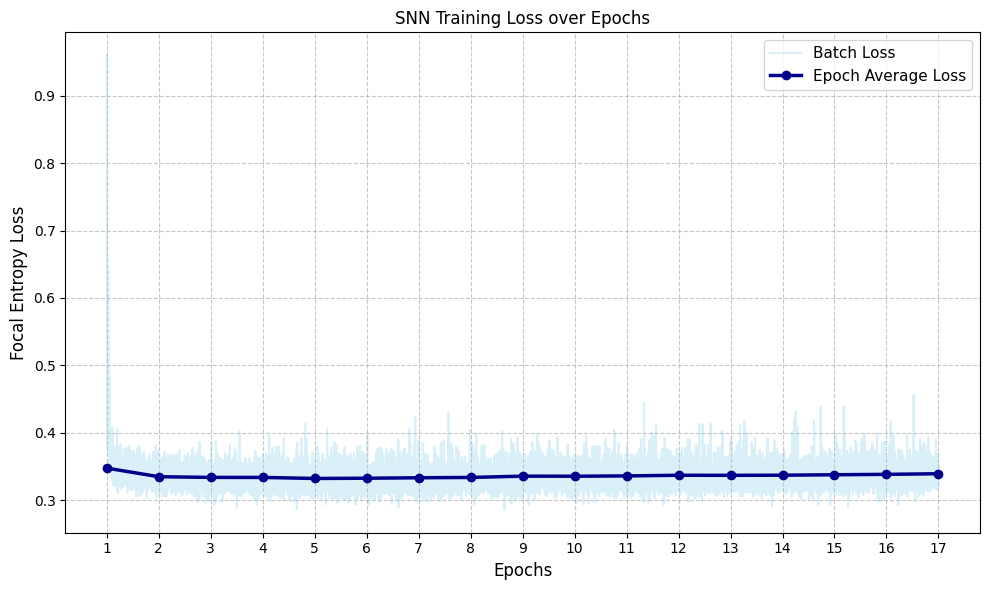

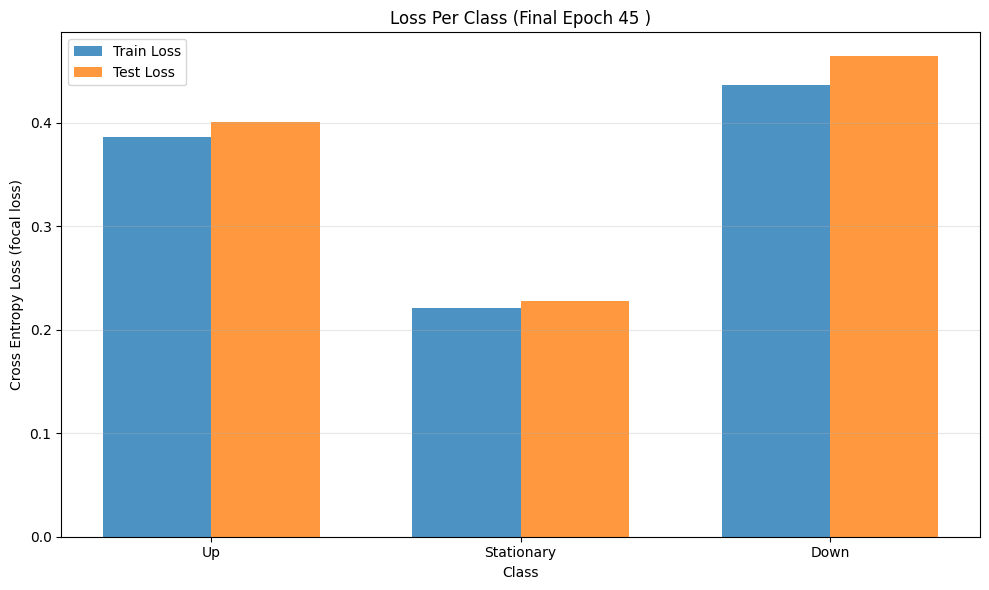

train loss per class: ['0.3860', '0.2210', '0.4372']
test loss per class: ['0.4014', '0.2279', '0.4644']
train per-class accuracy: [0.53430676 0.40114394 0.53471774]
test per-class accuracy: [0.5120342 0.4659424 0.5168957]
train overall: 0.4901 ** test overall: 0.4983


In [7]:
# visualizing results
import matplotlib.pyplot as plt
import numpy as np

batches_per_epoch = len(train_loader)
total_epochs = len(loss_hist) // batches_per_epoch
# average loss per epoch
loss_array = np.array(loss_hist)[:total_epochs * batches_per_epoch].reshape(total_epochs, batches_per_epoch)

epoch_losses = loss_array.mean(axis=1)
epochs_x = np.arange(1, total_epochs + 1)
batches_x = np.linspace(1, total_epochs, len(loss_hist))

plt.figure(figsize=(10, 6))
plt.plot(batches_x, loss_hist, color='skyblue', alpha=0.3, label='Batch Loss')
plt.plot(epochs_x, epoch_losses, color='darkblue', linewidth=2.5, marker='o', label='Epoch Average Loss')

plt.title("SNN Training Loss over Epochs", fontsize=12)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Focal Entropy Loss", fontsize=12)
plt.xticks(epochs_x)  
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc="upper right", fontsize=11)
plt.tight_layout()

plt.show()

### The testing and ensuration
train_per_class = per_class_accuracy(train_loader, net, device)
test_per_class = per_class_accuracy(test_loader, net, device)
plot_loss_per_class(train_loader, test_loader, net, loss_fn, device, epoch=45)

print(f"train per-class accuracy: {train_per_class}")
print(f"test per-class accuracy: {test_per_class}")
print(f"train overall: {train_per_class.mean():.4f} ** test overall: {test_per_class.mean():.4f}")

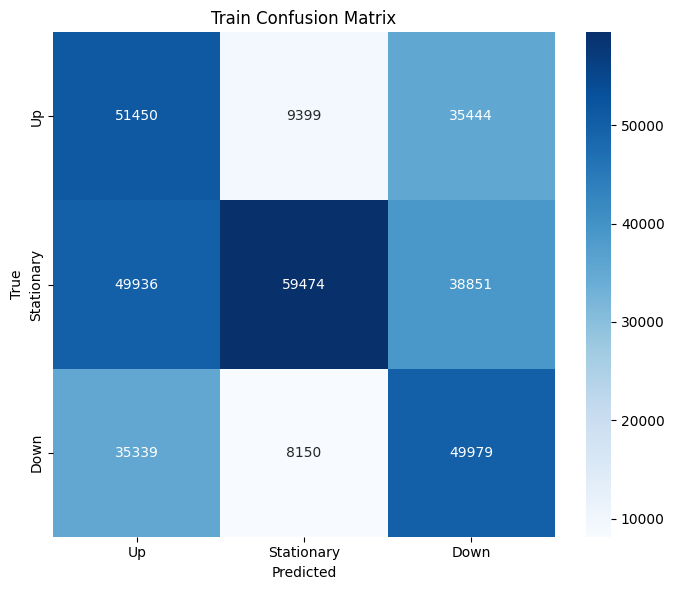


Train Classification Report:
              precision    recall  f1-score   support

          Up     0.3763    0.5343    0.4416     96293
  Stationary     0.7722    0.4011    0.5280    148261
        Down     0.4022    0.5347    0.4591     93468

    accuracy                         0.4760    338022
   macro avg     0.5169    0.4901    0.4762    338022
weighted avg     0.5571    0.4760    0.4843    338022

Macro F1:    0.4762
Weighted F1: 0.4843


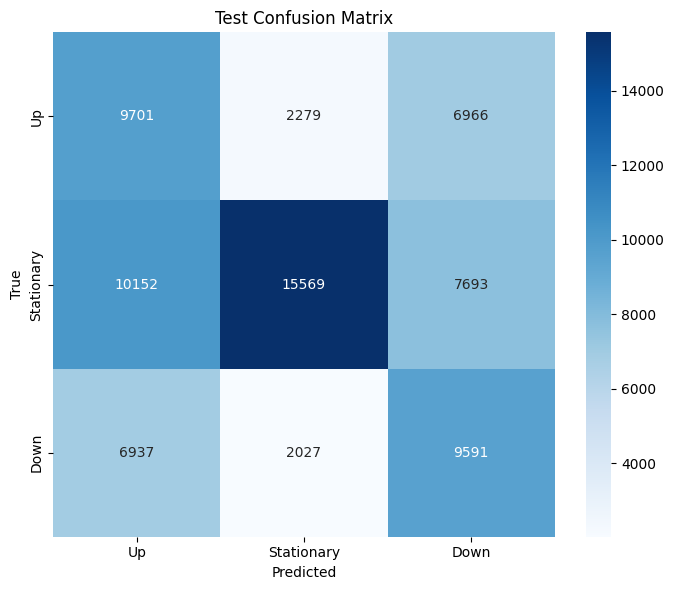


Test Classification Report:
              precision    recall  f1-score   support

          Up     0.3621    0.5120    0.4242     18946
  Stationary     0.7833    0.4659    0.5843     33414
        Down     0.3955    0.5169    0.4481     18555

    accuracy                         0.4916     70915
   macro avg     0.5137    0.4983    0.4856     70915
weighted avg     0.5693    0.4916    0.5059     70915

Macro F1:    0.4856
Weighted F1: 0.5059


In [8]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def get_all_predictions(data_loader, net, device):
    net.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for data, targets in data_loader:
            data = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()
            logits = net(data)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
    return torch.cat(all_targets).numpy(), torch.cat(all_preds).numpy()


def evaluate_full(data_loader, net, device, split_name="Test"):
    y_true, y_pred = get_all_predictions(data_loader, net, device)
    
    class_names = ['Up', 'Stationary', 'Down']
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{split_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
    # Full classification report (precision, recall, F1 per class)
    report = classification_report(y_true, y_pred, labels=[0, 1, 2],
                                     target_names=class_names, digits=4)
    print(f"\n{split_name} Classification Report:")
    print(report)
    
    # Macro and weighted F1 (single numbers for comparing against the paper)
    macro_f1 = f1_score(y_true, y_pred, labels=[0, 1, 2], average='macro')
    weighted_f1 = f1_score(y_true, y_pred, labels=[0, 1, 2], average='weighted')
    print(f"Macro F1:    {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    
    return cm, report, macro_f1, weighted_f1


# Run on both splits
print("="*60)
train_cm, train_report, train_macro_f1, train_weighted_f1 = evaluate_full(
    train_loader, net, device, split_name="Train"
)

print("="*60)
test_cm, test_report, test_macro_f1, test_weighted_f1 = evaluate_full(
    test_loader, net, device, split_name="Test"
)

/tmp/ipykernel_253/1927236563.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


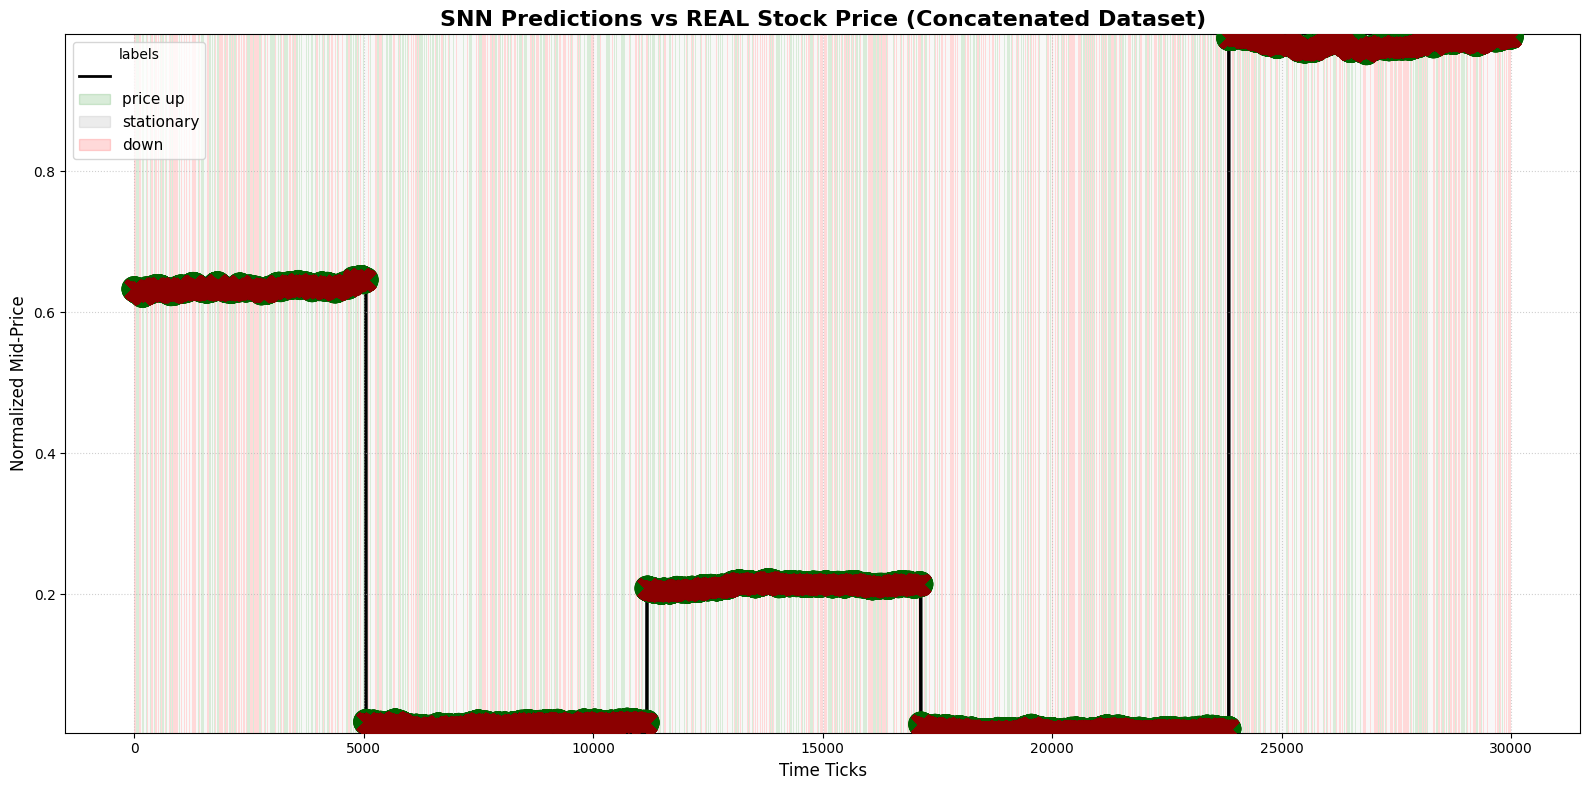


Tick   | P_t        | P_t+1      | label         | Target   | Prediction | Status  
0      | 0.63267    | 0.63289    | class[0]      | 0        | 2          | wrong
1      | 0.63289    | 0.63289    | class[1]      | 2        | 2          | correct * target mismatch
2      | 0.63289    | 0.63289    | class[1]      | 0        | 0          | correct * target mismatch
3      | 0.63289    | 0.63267    | class[2]      | 2        | 0          | wrong
4      | 0.63267    | 0.63244    | class[2]      | 0        | 0          | correct * target mismatch
5      | 0.63244    | 0.63244    | class[1]      | 2        | 0          | wrong * target mismatch
6      | 0.63244    | 0.63222    | class[2]      | 2        | 0          | wrong
7      | 0.63222    | 0.63200    | class[2]      | 0        | 2          | wrong * target mismatch
8      | 0.63200    | 0.63200    | class[1]      | 2        | 2          | correct * target mismatch
9      | 0.63200    | 0.63200    | class[1]      | 2        | 0       

In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def evaluate_and_visualize_concat(net, test_loader, first_test_file, device, window_size=30, limit=3000):
    """
    Evaluates a concatenated data_loader by accumulating batches until the 'limit' is reached.
    Assumes shuffle=False so the first N samples match the first raw text file.
    """
    net.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        # Iterate through the concatenated loader to gather enough batches
        for data, targets in test_loader:
            data = data.to(device)
            logits = net(data)
            preds = logits.argmax(dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            all_targets.extend(targets.cpu().numpy())
            
            # Stop once we have enough samples for the visualization limit
            if len(all_preds) >= limit:
                break

    # Cap exactly at the limit
    slice_preds = np.array(all_preds[:limit])
    slice_targets = np.array(all_targets[:limit])
    actual_limit = len(slice_preds)

    # Load the raw data from the FIRST file to get the continuous mid-prices
    # Since test_loader has shuffle=False, these perfectly align with the first N predictions
    raw_data = np.loadtxt(first_test_file) 
    raw_ask = raw_data[0, :]
    raw_bid = raw_data[2, :]
    raw_mid_prices = (raw_ask + raw_bid) / 2

    time_steps = np.arange(actual_limit)
     
    correct_mask = (slice_preds == slice_targets)
    wrong_mask = (slice_preds != slice_targets)

    # Align predictions with the raw data accounting for the sliding window
    start_idx = window_size - 1
    slice_prices = raw_mid_prices[start_idx : start_idx + actual_limit]

    # ---------------------------
    # Plotting
    # ---------------------------
    plt.figure(figsize=(16, 8))
    color_map = {0: 'green', 1: 'gray', 2: 'red'}

    for i in range(len(time_steps) - 1):
        label = slice_targets[i]
        if label == 0:
            color, alpha = 'green', 0.15
        elif label == 1:
            color, alpha = 'gray', 0.05
        elif label == 2:
            color, alpha = 'red', 0.15
        plt.axvspan(time_steps[i], time_steps[i+1], color=color, alpha=alpha, lw=0)
        
    plt.plot(time_steps, slice_prices, color='black', linewidth=2.5, zorder=1, label='Mid-Price')

    for c in range(3):
        mask = slice_preds == c
        if np.any(mask):
            plt.scatter(time_steps[mask], slice_prices[mask], 
                        color=color_map[c], s=80, edgecolor='black', zorder=2, 
                        label=f'SNN Predicted: Class {c}', alpha=1)
            
    if np.any(correct_mask):
        plt.scatter(time_steps[correct_mask], slice_prices[correct_mask], color='none',
                    edgecolor='darkgreen', marker='o', s=250, linewidths=2.5, zorder=3, label='Prediction: CORRECT')

    if np.any(wrong_mask):
        plt.scatter(time_steps[wrong_mask], slice_prices[wrong_mask], color='darkred',
                    marker='x', s=150, linewidths=3, zorder=4, label='Prediction: WRONG')

    plt.title("SNN Predictions vs REAL Stock Price (Concatenated Dataset)", fontsize=16, fontweight='bold')
    plt.xlabel("Time Ticks", fontsize=12)
    plt.ylabel("Normalized Mid-Price", fontsize=12)
    plt.ylim(slice_prices.min() - 0.0005, slice_prices.max() + 0.0005) 

    # Legend
    true_up = mpatches.Patch(color='green', alpha=0.15, label='price up')
    true_flat = mpatches.Patch(color='gray', alpha=0.15, label='stationary')
    true_down = mpatches.Patch(color='red', alpha=0.15, label='down')
    plt.legend(handles=[plt.Line2D([0], [0], color='black', lw=2), true_up, true_flat, true_down], 
               fontsize=11, title="labels")

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # ---------------------------
    # Logging
    # ---------------------------
    print("\n" + "="*85)
    print(f"{'Tick':<6} | {'P_t':<10} | {'P_t+1':<10} | {'label':<13} | {'Target':<8} | {'Prediction':<10} | {'Status':<8}")
    print("="*85)

    for i in range(actual_limit - 1):
        current_p = slice_prices[i]
        next_p = slice_prices[i+1]
        
        if next_p > current_p:
            actual_move = "class[0]"
        elif next_p < current_p:
            actual_move = "class[2]"
        else:
            actual_move = "class[1]"
            
        target_val = slice_targets[i]
        pred_val = slice_preds[i]
        
        status = "correct" if target_val == pred_val else "wrong"
        
        if (actual_move.startswith("class[0]") and target_val != 0) or \
           (actual_move.startswith("class[1]") and target_val != 1) or \
           (actual_move.startswith("class[2]") and target_val != 2):
            status += " * target mismatch"

        print(f"{i:<6} | {current_p:<10.5f} | {next_p:<10.5f} | {actual_move:<13} | {target_val:<8} | {pred_val:<10} | {status}")

    print("="*85)
    correct = np.sum(slice_preds == slice_targets)
    wrong = np.sum(slice_preds != slice_targets)
    print(f"Total mapped ticks: {actual_limit}")
    print(f"Correct: {correct} ({(correct/actual_limit)*100:.1f}%)")
    print(f"Wrong: {wrong}")

# ==========================================
# Run the visualization
# ==========================================
first_test_file = "/kaggle/input/datasets/firmwired/fi-2010/data/published/BenchmarkDatasets/BenchmarkDatasets/BenchmarkDatasets/NoAuction/NoAuction_MinMax/NoAuction_MinMax_Testing/Test_Dst_NoAuction_MinMax_CF_1.txt"

evaluate_and_visualize_concat(
    net=net, 
    test_loader=test_loader, 
    first_test_file=first_test_file, 
    device=device,
    window_size=30, 
    limit=30000
)


--- Running Memristor Crossbar Hardware Validation Sweep ---
SAF: 0.0% | Noise: 0.0% | Acc: 49.83% ± 0.00%
SAF: 0.0% | Noise: 2.0% | Acc: 49.93% ± 0.11%
SAF: 0.0% | Noise: 5.0% | Acc: 49.69% ± 0.12%
SAF: 0.0% | Noise: 8.0% | Acc: 49.38% ± 0.16%
SAF: 0.0% | Noise: 12.0% | Acc: 48.29% ± 0.19%
SAF: 1.0% | Noise: 0.0% | Acc: 49.79% ± 0.62%
SAF: 1.0% | Noise: 2.0% | Acc: 49.63% ± 0.44%
SAF: 1.0% | Noise: 5.0% | Acc: 49.08% ± 1.27%
SAF: 1.0% | Noise: 8.0% | Acc: 48.94% ± 0.40%
SAF: 1.0% | Noise: 12.0% | Acc: 47.84% ± 0.17%
SAF: 3.0% | Noise: 0.0% | Acc: 49.91% ± 0.63%
SAF: 3.0% | Noise: 2.0% | Acc: 49.62% ± 0.86%
SAF: 3.0% | Noise: 5.0% | Acc: 49.59% ± 0.55%
SAF: 3.0% | Noise: 8.0% | Acc: 48.60% ± 0.28%
SAF: 3.0% | Noise: 12.0% | Acc: 47.36% ± 0.52%
SAF: 5.0% | Noise: 5.0% | Acc: 47.74% ± 1.30%
SAF: 5.0% | Noise: 8.0% | Acc: 47.15% ± 0.87%
SAF: 5.0% | Noise: 12.0% | Acc: 46.96% ± 0.77%
SAF: 10.0% | Noise: 0.0% | Acc: 46.74% ± 1.66%
SAF: 10.0% | Noise: 2.0% | Acc: 46.29% ± 0.60%
SAF: 10.0% |

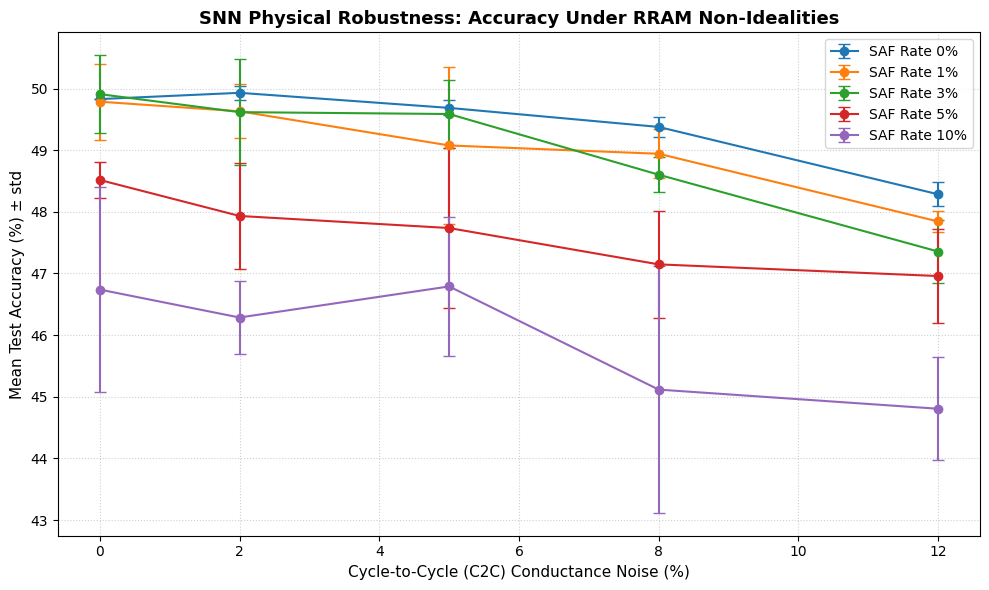

In [10]:
def validate_hardware_robustness(model_path, test_loader, device, n_trials=5):
    noise_sweeps = [0.0, 0.02, 0.05, 0.08, 0.12]
    saf_sweeps = [0.0, 0.01, 0.03, 0.05, 0.10]

    eval_net = HFT_Net_Optimized(num_levels=16, saf_rate=0.0, noise_std=0.0).to(device)
    eval_net.load_state_dict(torch.load(model_path, map_location=device))
    eval_net.eval()

    results = {}
    print("\n--- Running Memristor Crossbar Hardware Validation Sweep ---")
    for saf in saf_sweeps:
        results[saf] = {'mean': [], 'std': []}
        for noise in noise_sweeps:
            trial_accs = []
            for trial in range(n_trials):
                for name, module in eval_net.named_modules():
                    if isinstance(module, MemristorCrossbarLinear):
                        module.generate_saf_masks(saf)  # fresh defect draw each trial
                        module.noise_std = noise
                        module.force_noise_eval = True
                accs = per_class_accuracy(test_loader, eval_net, device)
                trial_accs.append(accs.mean())

            mean_acc = np.mean(trial_accs)
            std_acc = np.std(trial_accs)
            results[saf]['mean'].append(mean_acc)
            results[saf]['std'].append(std_acc)
            print(f"SAF: {saf*100:.1f}% | Noise: {noise*100:.1f}% | "
                  f"Acc: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")

    plt.figure(figsize=(10, 6))
    for saf, data in results.items():
        means = [a*100 for a in data['mean']]
        stds = [s*100 for s in data['std']]
        plt.errorbar([n*100 for n in noise_sweeps], means, yerr=stds,
                     marker='o', capsize=4, label=f'SAF Rate {saf*100:.0f}%')

    plt.title("SNN Physical Robustness: Accuracy Under RRAM Non-Idealities", fontsize=13, fontweight='bold')
    plt.xlabel("Cycle-to-Cycle (C2C) Conductance Noise (%)", fontsize=11)
    plt.ylabel("Mean Test Accuracy (%) ± std", fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results

results = validate_hardware_robustness('best_model.pt', test_loader, device, n_trials=5)

In [11]:
%%bash
# 1. Create a writable directory and copy the NeuroSIM codebase there
mkdir -p /kaggle/working/NeuroSIM
cp -r /kaggle/input/datasets/firmwired/neurosim/DNN_NeuroSim_V2.1/Training_pytorch/NeuroSIM/* /kaggle/working/NeuroSIM/

cd /kaggle/working/NeuroSIM/

# 2. Convert text line endings from Windows (CRLF) to Linux (LF) to prevent script parsing bugs
sed -i 's/\r$//' *

# 3. Clean up any previous partial compilation fragments and build the native Linux binary
make clean 
make

# 4. Explicitly mark the built binary as an executable file
chmod +x ./main

# 5. Confirm the executable exists in the writable working space
ls -la ./main

g++ -MM -fopenmp -fPIC -g -O3 -std=c++0x Adder.cpp AdderTree.cpp BitShifter.cpp Buffer.cpp Bus.cpp Chip.cpp Comparator.cpp CurrentSenseAmp.cpp DecoderDriver.cpp DeMux.cpp DFF.cpp DRAM.cpp formula.cpp FunctionUnit.cpp HTree.cpp main.cpp MaxPooling.cpp MultilevelSAEncoder.cpp MultilevelSenseAmp.cpp Mux.cpp NewMux.cpp NewSwitchMatrix.cpp Param.cpp Precharger.cpp ProcessingUnit.cpp ReadCircuit.cpp RowDecoder.cpp SarADC.cpp SenseAmp.cpp ShiftAdd.cpp Sigmoid.cpp SramNewSA.cpp SRAMWriteDriver.cpp SubArray.cpp SwitchMatrix.cpp Technology.cpp Tile.cpp VoltageSenseAmp.cpp WeightGradientUnit.cpp WLDecoderOutput.cpp WLNewDecoderDriver.cpp > .depend;
rm -f main
rm -f main.exe
rm -f Adder.o AdderTree.o BitShifter.o Buffer.o Bus.o Chip.o Comparator.o CurrentSenseAmp.o DecoderDriver.o DeMux.o DFF.o DRAM.o formula.o FunctionUnit.o HTree.o main.o MaxPooling.o MultilevelSAEncoder.o MultilevelSenseAmp.o Mux.o NewMux.o NewSwitchMatrix.o Param.o Precharger.o ProcessingUnit.o ReadCircuit.o RowDecoder.o SarAD

AdderTree.cpp: In member function ‘void AdderTree::CalculateArea(double, double, AreaModify)’:
AdderTree.cpp:88:45: warning: passing NULL to non-pointer argument 1 of ‘void Adder::CalculateArea(double, double, AreaModify)’ [-Wconversion-null]
   88 |                         adder.CalculateArea(NULL, _newWidth, NONE);
      |                                             ^~~~
In file included from AdderTree.h:47,
                 from AdderTree.cpp:43:
Adder.h:60:35: note:   declared here
   60 |         void CalculateArea(double _newHeight, double _newWidth, AreaModify _option);
      |                            ~~~~~~~^~~~~~~~~~
AdderTree.cpp:92:57: warning: passing NULL to non-pointer argument 2 of ‘void Adder::CalculateArea(double, double, AreaModify)’ [-Wconversion-null]
   92 |                         adder.CalculateArea(_newHeight, NULL, NONE);
      |                                                         ^~~~
In file included from AdderTree.h:47,
                 from AdderTree

In [12]:
 
%%bash
cd /kaggle/working/NeuroSIM/

# 1. Shrink BOTH Rows and Columns for the Inference Arrays
sed -i 's/numRowSubArray = 128;/numRowSubArray = 4;/g' Param.cpp
sed -i 's/numColSubArray = 128;/numColSubArray = 4;/g' Param.cpp

# 2. Shrink BOTH Rows and Columns for the Weight Gradient Arrays (if applicable)
sed -i 's/numRowSubArrayWG = 128;/numRowSubArrayWG = 4;/g' Param.cpp
sed -i 's/numColSubArrayWG = 128;/numColSubArrayWG = 4;/g' Param.cpp

# 3. Print the lines to verify the change
grep -E "numRowSubArray|numColSubArray" Param.cpp

# 4. Recompile with the proper square 32x32 arrays
make clean
make
chmod +x ./main

	numRowSubArray = 4;               // # of rows in single subArray
	numColSubArray = 4;               // # of columns in single subArray
	numRowSubArrayWG = 4;             // # of rows of single SRAM subArray in "gradient calculation of weight"
	numColSubArrayWG = 4;             // # of columns of single SRAM subArray in "gradient calculation of weight"
g++ -MM -fopenmp -fPIC -g -O3 -std=c++0x Adder.cpp AdderTree.cpp BitShifter.cpp Buffer.cpp Bus.cpp Chip.cpp Comparator.cpp CurrentSenseAmp.cpp DecoderDriver.cpp DeMux.cpp DFF.cpp DRAM.cpp formula.cpp FunctionUnit.cpp HTree.cpp main.cpp MaxPooling.cpp MultilevelSAEncoder.cpp MultilevelSenseAmp.cpp Mux.cpp NewMux.cpp NewSwitchMatrix.cpp Param.cpp Precharger.cpp ProcessingUnit.cpp ReadCircuit.cpp RowDecoder.cpp SarADC.cpp SenseAmp.cpp ShiftAdd.cpp Sigmoid.cpp SramNewSA.cpp SRAMWriteDriver.cpp SubArray.cpp SwitchMatrix.cpp Technology.cpp Tile.cpp VoltageSenseAmp.cpp WeightGradientUnit.cpp WLDecoderOutput.cpp WLNewDecoderDriver.cpp > .depend

AdderTree.cpp: In member function ‘void AdderTree::CalculateArea(double, double, AreaModify)’:
AdderTree.cpp:88:45: warning: passing NULL to non-pointer argument 1 of ‘void Adder::CalculateArea(double, double, AreaModify)’ [-Wconversion-null]
   88 |                         adder.CalculateArea(NULL, _newWidth, NONE);
      |                                             ^~~~
In file included from AdderTree.h:47,
                 from AdderTree.cpp:43:
Adder.h:60:35: note:   declared here
   60 |         void CalculateArea(double _newHeight, double _newWidth, AreaModify _option);
      |                            ~~~~~~~^~~~~~~~~~
AdderTree.cpp:92:57: warning: passing NULL to non-pointer argument 2 of ‘void Adder::CalculateArea(double, double, AreaModify)’ [-Wconversion-null]
   92 |                         adder.CalculateArea(_newHeight, NULL, NONE);
      |                                                         ^~~~
In file included from AdderTree.h:47,
                 from AdderTree

In [ ]:
import numpy as np
import torch
from sklearn.metrics import f1_score, classification_report

def evaluate_environment_latency(model, dataloader):
    # Lock model to a single T4 to ensure an identical hardware footprint
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    all_preds = []
    all_targets = []
    latencies = []
    
    # Microsecond-precise T4 hardware timers
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    
    # Warm up the T4 memory cache before timing
    dummy_shape = next(iter(dataloader))[0][0:1].shape
    dummy_input = torch.randn(dummy_shape).to(device)
    for _ in range(20):
        _ = model(dummy_input)
        
    print(f"Timing inference on: {torch.cuda.get_device_name(0)}")
    
    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            
            start_event.record()
            outputs = model(batch_x)
            end_event.record()
            
            torch.cuda.synchronize()  # Force execution sync on T4 core
            
            batch_ms = start_event.elapsed_time(end_event)
            # Normalize to microseconds (µs) per window
            per_sample_us = (batch_ms * 1000) / batch_x.size(0)
            latencies.append(per_sample_us)
            
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(batch_y.numpy())
            
    macro_f1 = f1_score(all_targets, all_preds, average='macro')
    print(f"Avg T4 Latency: {np.mean(latencies):.2f} µs | Macro-F1: {macro_f1:.4f}")
    return np.mean(latencies), macro_f1

# Execute this in Environment 1 (LSTM) and Environment 2 (MSNN)
avg_lat, macro_f1 = evaluate_environment_latency(net, test_loader)


: 

In [ ]:
import torch
import torch.nn as nn
import numpy as np

# ---------------------------------------------------------
# 1. Define the Standard LSTM Architecture
# ---------------------------------------------------------
class HFT_LSTM_Baseline(nn.Module):
    def __init__(self, input_size=288, hidden_size=128, num_layers=1, num_classes=3):
        super(HFT_LSTM_Baseline, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Batch_first=True expects input shape: (batch_size, time_steps, features)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3 if num_layers > 1 else 0)
        
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        # x shape from your dataloader: (batch_size, 30, 288)
        
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))  
        
        # out shape: (batch_size, time_steps, hidden_size)
        # We only want the output from the final time step (step 30)
        final_step_out = out[:, -1, :]
        
        final_step_out = self.drop(final_step_out)
        logits = self.fc(final_step_out)
        
        return logits

# ---------------------------------------------------------
# 2. Setup the Training Loop
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running LSTM on: {device}")

# Initialize the LSTM
lstm_net = HFT_LSTM_Baseline(input_size=288, hidden_size=128, num_layers=1, num_classes=3).to(device)

# We reuse your exact FocalLoss and class weights
optimizer_lstm = torch.optim.Adam(lstm_net.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_lstm = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_lstm, T_max=40, eta_min=1e-6)

num_epochs = 40
best_lstm_acc = 0.0
patience = 15
patience_counter = 0

print("\n--- Starting LSTM Baseline Training ---")
for epoch in range(num_epochs):
    lstm_net.train()
    
    for batch_idx, (data, targets) in enumerate(train_loader):
        # Data comes in as (batch, 30, 288)
        data = data.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).long()
        
        optimizer_lstm.zero_grad(set_to_none=True)
        
        # Forward pass (no time-loop needed, LSTM handles it internally)
        logits = lstm_net(data)
        loss_val = loss_fn(logits, targets) # Reusing your FocalLoss
        
        loss_val.backward()
        torch.nn.utils.clip_grad_norm_(lstm_net.parameters(), max_norm=1.0)
        optimizer_lstm.step()
        
    scheduler_lstm.step()
    
    # ---------------------------------------------------------
    # 3. Evaluation
    # ---------------------------------------------------------
    lstm_net.eval()
    test_losses, test_per_class = evaluate_epoch(eval_subset_loader, lstm_net, loss_fn, device)
    avg_test_loss = np.nanmean(test_losses)
    mean_test_acc = test_per_class.mean()
    
    if mean_test_acc > best_lstm_acc:
        best_lstm_acc = mean_test_acc
        patience_counter = 0
        torch.save(lstm_net.state_dict(), 'best_lstm_model.pt')
        print(f"Epoch {epoch}: NEW BEST LSTM | Mean Acc: {mean_test_acc*100:.2f}% | Loss: {avg_test_loss:.4f}")
    else:
        patience_counter += 1 
        print(f"Epoch {epoch}: Mean Acc: {mean_test_acc*100:.2f}% | Loss: {avg_test_loss:.4f} (Patience: {patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print(f"Early stopping triggered for LSTM at epoch {epoch}.")
            break

# ---------------------------------------------------------
# 4. Final Evaluation against the full Test Set
# ---------------------------------------------------------
lstm_net.load_state_dict(torch.load('best_lstm_model.pt', map_location=device))
lstm_net.eval()

print("\n--- Final LSTM Evaluation on Full Test Set ---")
lstm_test_losses, lstm_test_per_class = evaluate_epoch(test_loader, lstm_net, loss_fn, device)
print(f"LSTM Test per-class accuracy: {lstm_test_per_class}")
print(f"LSTM Overall Balanced Accuracy: {lstm_test_per_class.mean()*100:.2f}%")

Analyzing delta-encoded spikes for operational sparsity...
Dataset Sparsity:       92.89% (Zeros)
Activity Factor (α):     7.11% (Active Spikes)
